In [19]:
import yfinance as yf
import math as m
import pandas as pd

brent = yf.download('BZ=F', start='2021-01-01', end='2024-01-01')
df_brent = brent[['Close']].copy()
df_brent.columns = ['price']

df_brent['ma_10'] = df_brent['price'].rolling(10).mean()
df_brent['ma_50'] = df_brent['price'].rolling(50).mean()
df_brent['returns'] = (df_brent['price'] - df_brent['price'].shift(1)) / df_brent['price'].shift(1)
df_brent['vol_20'] = (df_brent['returns'].rolling(20).std()) * (m.sqrt(252))

df_brent = df_brent.iloc[49:]
df_brent.head()


[*********************100%***********************]  1 of 1 completed

49


,price,ma_10,ma_50,returns,vol_20
Date,,,,,
2021-03-16,68.389999,67.994999,60.8070,-0.007114,0.343394
2021-03-17,68.000000,68.387999,61.1452,-0.005703,0.342205
2021-03-18,63.279999,68.041999,61.3388,-0.069412,0.427587
2021-03-19,64.529999,67.558999,61.5434,0.019753,0.428880
2021-03-22,64.620003,67.196999,61.7482,0.001395,0.407998


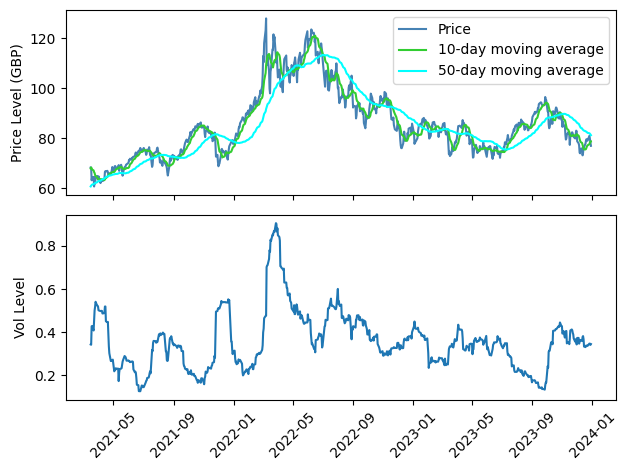

In [20]:
import matplotlib.pyplot as plt

fig,ax= plt.subplots(2,1, sharex=True)
ax[0].plot( df_brent['price'], label='Price', color='steelblue')
ax[0].plot(df_brent['ma_10'], label='10-day moving average', color='limegreen')
ax[0].plot(df_brent['ma_50'], label='50-day moving average', color='cyan')
ax[0].set_ylabel('Price Level (GBP)')
ax[0].legend(loc='upper right')

ax[1].plot(df_brent['vol_20'], label='20-day annualised rolling volatility')
ax[1].set_ylabel('Vol Level')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

dxy = yf.download('DX-Y.NYB', start='2021-01-01', end='2024-01-01')
df_dxy = dxy[['Close']].copy()
df_dxy.columns = df_dxy.columns.droplevel(1)
df_dxy = df_dxy.rename(columns={'Close': 'price'})

df_combined = df_brent.join(df_dxy, how='inner', lsuffix='_brent', rsuffix='_dxy')
df_combined = df_combined.drop(columns=['ma_10', 'ma_50', 'vol_20', 'returns'])
df_combined.head(10)


[*********************100%***********************]  1 of 1 completed


,price_brent,price_dxy
Date,,
2021-03-16,68.389999,91.870003
2021-03-17,68.000000,91.400002
2021-03-18,63.279999,91.849998
2021-03-19,64.529999,91.919998
2021-03-22,64.620003,91.800003
2021-03-23,60.790001,92.339996
2021-03-24,64.410004,92.529999
2021-03-25,61.950001,92.879997
2021-03-26,64.570000,92.769997


Rolling correlation is computed on daily returns rather than price levels. Price levels can trend (violating stationarity), inflate correlation spuriously, and exhibit heteroscedasticity. Returns fluctuate around zero with roughly stable variance, giving a cleaner correlation signal.

In [ ]:
df_combined['returns_dxy'] = df_combined['price_dxy'].pct_change()
df_combined['returns_brent'] = df_combined['price_brent'].pct_change()
df_combined.head()


In [23]:
df_combined['rolling_corr'] = df_combined['returns_brent'].rolling(60).corr(df_combined['returns_dxy'])
df_combined = df_combined.iloc[60:]
df_combined.head()


,price_brent,price_dxy,returns_dxy,returns_brent,rolling_corr
Date,,,,,
2021-06-10,72.519997,90.080002,-0.000444,0.004154,-0.237965
2021-06-11,72.690002,90.559998,0.005329,0.002344,-0.243406
2021-06-14,72.860001,90.519997,-0.000442,0.002339,-0.179419
2021-06-15,73.989998,90.540001,0.000221,0.015509,-0.182994
2021-06-16,74.389999,91.129997,0.006516,0.005406,-0.172465


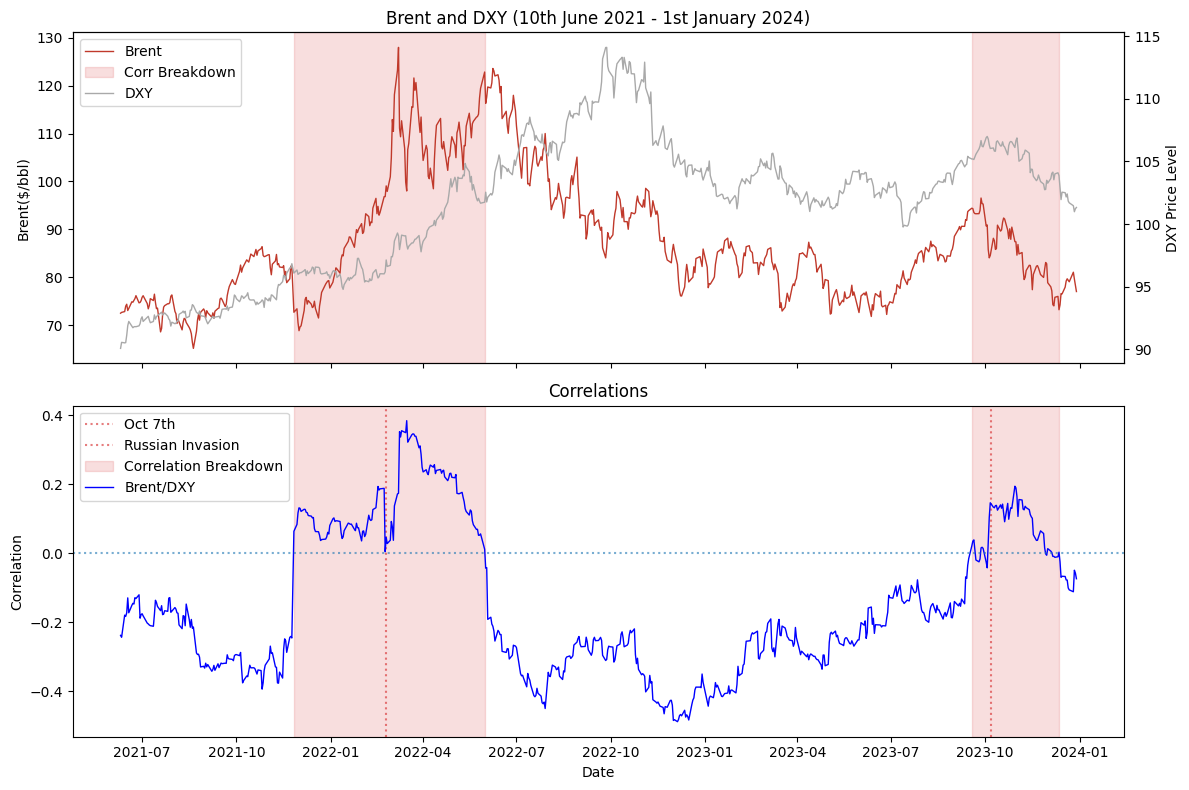

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df_combined['price_brent'], label='Brent', color='#c0392b', lw=1)
ax[0].set_ylabel('Brent ($/bbl)')
ax[0].set_title('Brent and DXY (10th June 2021 - 1st January 2024)')

ax0_right = ax[0].twinx()
ax0_right.plot(df_combined['price_dxy'], label='DXY', color='darkgray', lw=1)
ax0_right.set_ylabel('DXY (Index)')

ax[0].axvspan(pd.to_datetime('2021-11-26'), pd.to_datetime('2022-05-31'), color='tab:red', alpha=0.15, label='Correlation Breakdown')
ax[0].axvspan(pd.to_datetime('2023-09-18'), pd.to_datetime('2023-12-12'), color='tab:red', alpha=0.15)

lines1, labels1 = ax[0].get_legend_handles_labels()
lines2, labels2 = ax0_right.get_legend_handles_labels()
ax[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax[1].axvline(pd.to_datetime('2022-02-24'), linestyle=':', color='tab:red', alpha=0.6, label='Russian Invasion')
ax[1].axvline(pd.to_datetime('2023-10-07'), linestyle=':', color='tab:red', alpha=0.6, label='Oct 7th Attack')
ax[1].axvspan(pd.to_datetime('2021-11-26'), pd.to_datetime('2022-05-31'), color='tab:red', alpha=0.15, label='Correlation Breakdown')
ax[1].axvspan(pd.to_datetime('2023-09-18'), pd.to_datetime('2023-12-12'), color='tab:red', alpha=0.15)

ax[1].plot(df_combined['rolling_corr'], label='Brent/DXY', color='blue', lw=1)
ax[1].axhline(0, linestyle=':', alpha=0.6)
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Correlation')
ax[1].set_title('60-Day Rolling Correlation: Brent vs DXY')
ax[1].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Typically a stronger dollar has two implications: oil becomes more expensive in local currencies, and demand gets dampened which pushes prices down. However, when a dominant macro regime drives both assets in the same direction, the mechanical link breaks down.

The typical negative relationship between Brent and the US dollar inverted on two occasions: in early 2022 and late 2023. Whilst the inversion in 2022 reached its peak as a result of the Russian invasion of Ukraine in February, the correlation had already broken down 3 months earlier. The Fed led a post-pandemic global hiking cycle, and raised interest rates aggressively compared to lagging ECB and BoJ. This put upwards pressure on the Dollar which accelerated into Q2 of 2022, benefitting further from safe-haven demand and US relative economic strength.

Simultaneously, Brent was rising due to concerns about an impending Russian invasion, where investors were repricing risk to reflect sanctions and supply concerns. Additionally, post-covid recovery put persistent upwards pressure on oil demand that continued into mid 2022, whilst multi-quarter drawdowns meant inventories were tight even before the war. The invasion acted as a catalyst that exposed structural fragility in energy markets. Following the Russian invasion on the 24th February, the correlation reached its peak at ~0.4. This represented a unique inversion fuelled by USD safe-haven demand and tight oil supply, two independent drivers that overwhelmed the normal mechanical link.

The correlation also inverted in late 2023, but through the opposite channel: both DXY and Brent were falling together. The US dollar strengthened in mid 2023, as the Fed's higher-for-longer rate stance attracted foreign capital flows. But towards the end of the year, markets revised growth outlooks, expecting easing inflation and future rate cuts. Simultaneously, a relative Chinese slowdown and weakness in international manufacturing sectors decreased demand for oil, pushing Brent lower.

Furthermore, higher exports from non-OPEC countries - particularly from the US, Brazil and Norway - offset OPEC+ production cuts and contributed to the overall increase in oil supply in the second half of the year. Whilst the October 7th attack triggered an immediate geopolitical risk premium, investors concluded the impacts would be short-lived rather than structurally bullish.

Towards the end of 2023, weak demand for the dollar and weak demand for oil pushed both assets down and inverted the typical negative correlation.

In both cases, the relationship inverted as Brent Crude and the Dollar moved in tandem. In 2022, both assets were rising together in a global tightening environment and in late 2023, both assets fell together in anticipation of global softening. To conclude, the negative relationship breaks down when macro influences overwhelm the mechanical petrodollar link.